In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## train data


In [2]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/취업 포폴/ashrae 에너지 예측 분석/data collection/train.csv')


In [3]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   building_id    int64  
 1   meter          int64  
 2   timestamp      object 
 3   meter_reading  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 616.9+ MB


In [4]:
df['meter_reading'].describe()

,meter_reading
count,2.021610e+07
mean,2.117121e+03
std,1.532356e+05
min,0.000000e+00
25%,1.830000e+01
50%,7.877500e+01
75%,2.679840e+02
max,2.190470e+07


In [5]:
df['meter'].value_counts()

,count
meter,
0,12060910
1,4182440
2,2708713
3,1264037


In [6]:
df['timestamp']

,timestamp
0,2016-01-01 00:00:00
1,2016-01-01 00:00:00
2,2016-01-01 00:00:00
3,2016-01-01 00:00:00
4,2016-01-01 00:00:00
...,...
20216095,2016-12-31 23:00:00
20216096,2016-12-31 23:00:00
20216097,2016-12-31 23:00:00
20216098,2016-12-31 23:00:00


## building_metadata

In [7]:
import pandas as pd

# 데이터 로드
df_b= pd.read_csv('/content/drive/MyDrive/취업 포폴/ashrae 에너지 예측 분석/data collection/building_metadata.csv')


In [8]:
df_b.shape
df_b.head()
df_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_id      1449 non-null   int64  
 1   building_id  1449 non-null   int64  
 2   primary_use  1449 non-null   object 
 3   square_feet  1449 non-null   int64  
 4   year_built   675 non-null    float64
 5   floor_count  355 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 68.1+ KB


In [9]:
df_b['primary_use'].value_counts()

,count
primary_use,
Education,549
Office,279
Entertainment/public assembly,184
Public services,156
Lodging/residential,147
Other,25
Healthcare,23
Parking,22
Warehouse/storage,13


In [10]:
df_b['square_feet'].value_counts()

,count
square_feet,
387638,7
22000,4
53130,4
24456,4
69600,3
...,...
61151,1
51622,1
112536,1


In [11]:
df_b['year_built'].isnull().sum()

np.int64(774)

## weather_train

In [12]:
import pandas as pd

# 데이터 로드
df_w= pd.read_csv('/content/drive/MyDrive/취업 포폴/ashrae 에너지 예측 분석/data collection/weather_train.csv')


In [13]:
df_w.isnull().sum()

,0
site_id,0
timestamp,0
air_temperature,55
cloud_coverage,69173
dew_temperature,113
precip_depth_1_hr,50289
sea_level_pressure,10618
wind_direction,6268
wind_speed,304


In [14]:
df_w['air_temperature'].describe()

,air_temperature
count,139718.000000
mean,14.418106
std,10.626595
min,-28.900000
25%,7.200000
50%,15.000000
75%,22.200000
max,47.200000


In [15]:
#datetime 변환
df_w['timestamp'] = pd.to_datetime(df_w['timestamp'])
df_w = df_w.sort_values('timestamp')

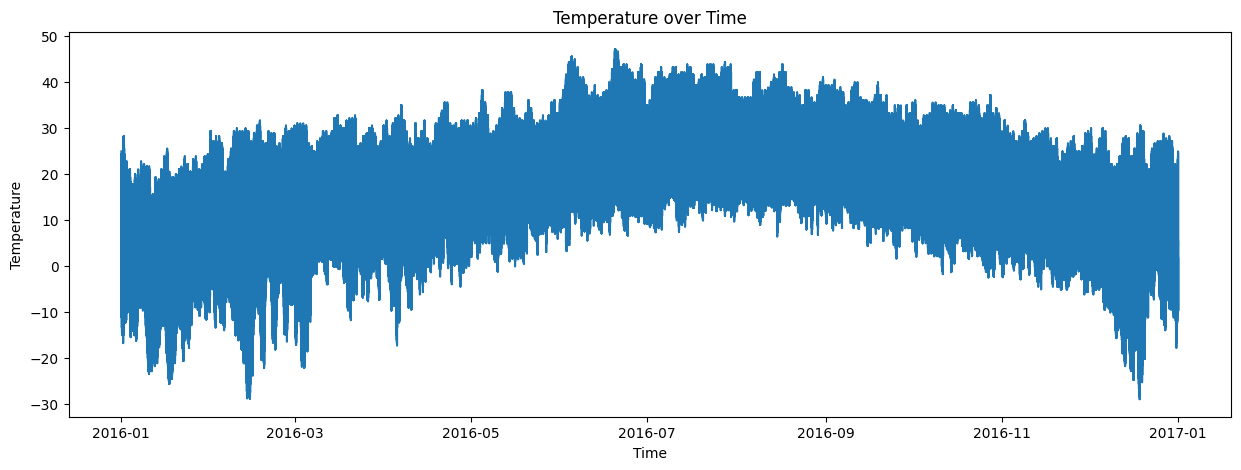

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df_w['timestamp'], df_w['air_temperature'])
plt.title('Temperature over Time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

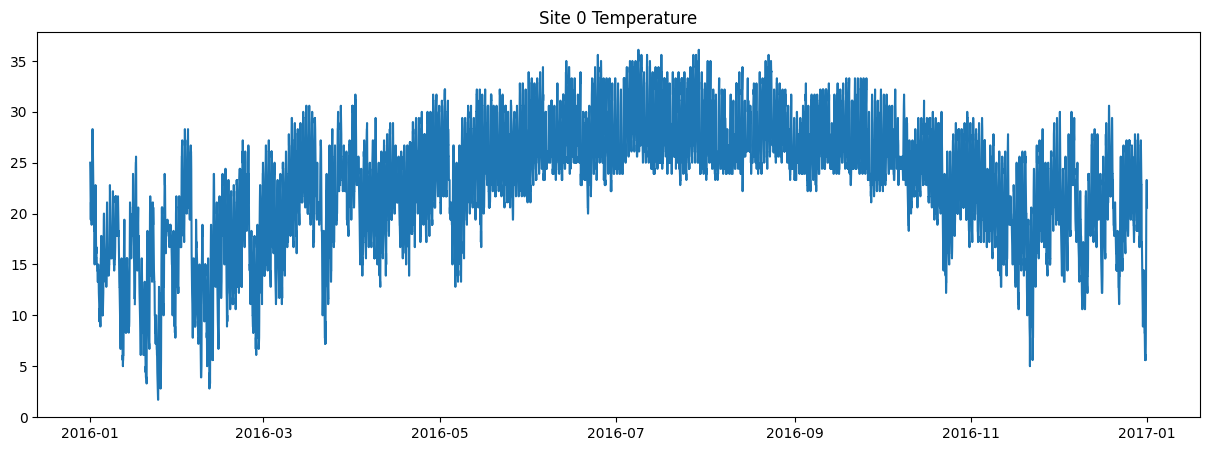

In [17]:
#site별 날씨 확인
site_0 = df_w[df_w['site_id'] == 0]

plt.figure(figsize = (15,5))
plt.plot(site_0['timestamp'], site_0['air_temperature'])
plt.title('Site 0 Temperature')
plt.show()

In [18]:
df_w['time_diff'] = df_w['timestamp'].diff()
df_w['time_diff'].value_counts().head()

,count
time_diff,
0 days 00:00:00,130989
0 days 01:00:00,8783


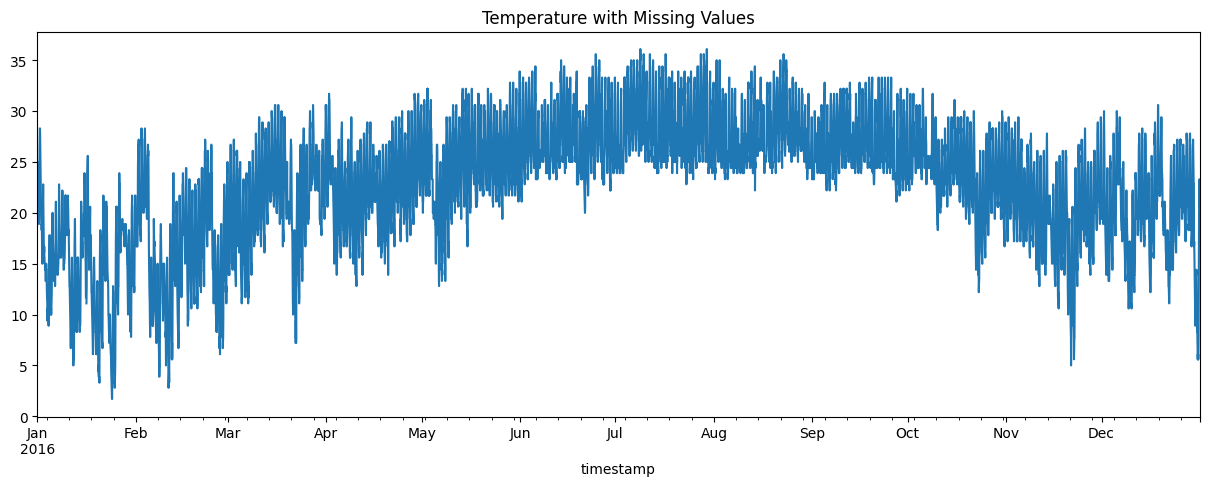

In [19]:
site_0.set_index('timestamp')['air_temperature'].plot(figsize=(15,5))
plt.title('Temperature with Missing Values')
plt.show()

## 데이터 통합

In [20]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_w['timestamp'] = pd.to_datetime(df_w['timestamp'])

In [21]:
df = df.merge(df_b, on='building_id', how='left')
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count
0,0,0,2016-01-01 00:00:00,0.000,0,Education,7432,2008.0,NaN
1,1,0,2016-01-01 00:00:00,0.000,0,Education,2720,2004.0,NaN
2,2,0,2016-01-01 00:00:00,0.000,0,Education,5376,1991.0,NaN
3,3,0,2016-01-01 00:00:00,0.000,0,Education,23685,2002.0,NaN
4,4,0,2016-01-01 00:00:00,0.000,0,Education,116607,1975.0,NaN
...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750,15,Entertainment/public assembly,19619,1914.0,NaN
20216096,1445,0,2016-12-31 23:00:00,4.825,15,Education,4298,NaN,NaN
20216097,1446,0,2016-12-31 23:00:00,0.000,15,Entertainment/public assembly,11265,1997.0,NaN
20216098,1447,0,2016-12-31 23:00:00,159.575,15,Lodging/residential,29775,2001.0,NaN


In [22]:
df = df.merge(df_w, on=['site_id', 'timestamp'], how='left')
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,time_diff
0,0,0,2016-01-01 00:00:00,0.000,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
1,1,0,2016-01-01 00:00:00,0.000,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
2,2,0,2016-01-01 00:00:00,0.000,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
3,3,0,2016-01-01 00:00:00,0.000,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
4,4,0,2016-01-01 00:00:00,0.000,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750,15,Entertainment/public assembly,19619,1914.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days
20216096,1445,0,2016-12-31 23:00:00,4.825,15,Education,4298,NaN,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days
20216097,1446,0,2016-12-31 23:00:00,0.000,15,Entertainment/public assembly,11265,1997.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days
20216098,1447,0,2016-12-31 23:00:00,159.575,15,Lodging/residential,29775,2001.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days


In [23]:
print(df.shape)
df.head()

(20216100, 17)


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,time_diff
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT


In [24]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
floor_count,16709167
year_built,12127645
cloud_coverage,8825365
precip_depth_1_hr,3749023
wind_direction,1449048
sea_level_pressure,1231669
wind_speed,143676
dew_temperature,100140
air_temperature,96658
time_diff,90598


In [25]:
df[['building_id', 'site_id']].drop_duplicates().head()

,building_id,site_id
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


## EDA


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [27]:
df.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed', 'time_diff'],
      dtype='object')

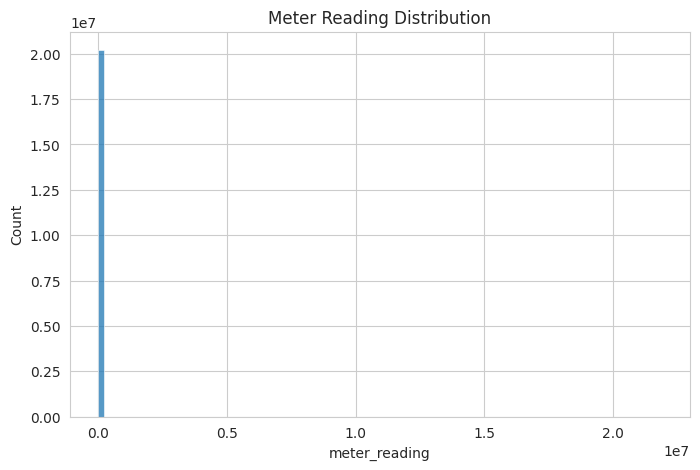

In [28]:
# meter_reading 분포
plt.figure(figsize=(8,5))
sns.histplot(df['meter_reading'], bins=100)
plt.title('Meter Reading Distribution')
plt.show()

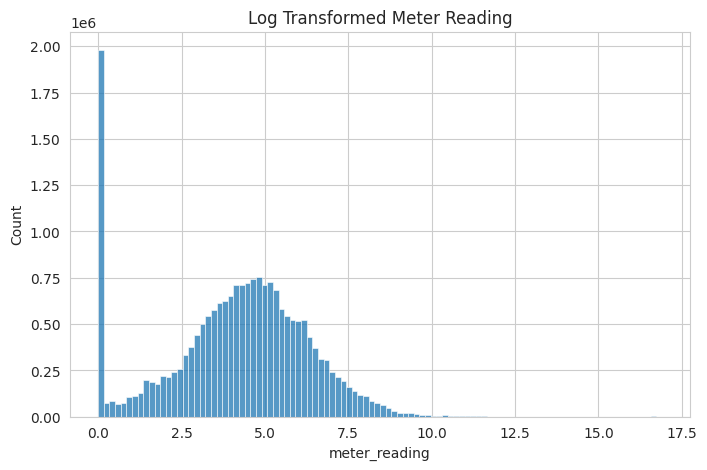

In [29]:
# meter_reading 분포 로그변환
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['meter_reading']), bins=100)
plt.title('Log Transformed Meter Reading')
plt.show()

In [30]:
# 시간 feature
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

In [31]:
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,time_diff,hour,dayofweek,month
0,0,0,2016-01-01 00:00:00,0.000,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT,0,4,1
1,1,0,2016-01-01 00:00:00,0.000,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT,0,4,1
2,2,0,2016-01-01 00:00:00,0.000,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT,0,4,1
3,3,0,2016-01-01 00:00:00,0.000,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT,0,4,1
4,4,0,2016-01-01 00:00:00,0.000,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaT,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750,15,Entertainment/public assembly,19619,1914.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days,23,5,12
20216096,1445,0,2016-12-31 23:00:00,4.825,15,Education,4298,NaN,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days,23,5,12
20216097,1446,0,2016-12-31 23:00:00,0.000,15,Entertainment/public assembly,11265,1997.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days,23,5,12
20216098,1447,0,2016-12-31 23:00:00,159.575,15,Lodging/residential,29775,2001.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,0 days,23,5,12


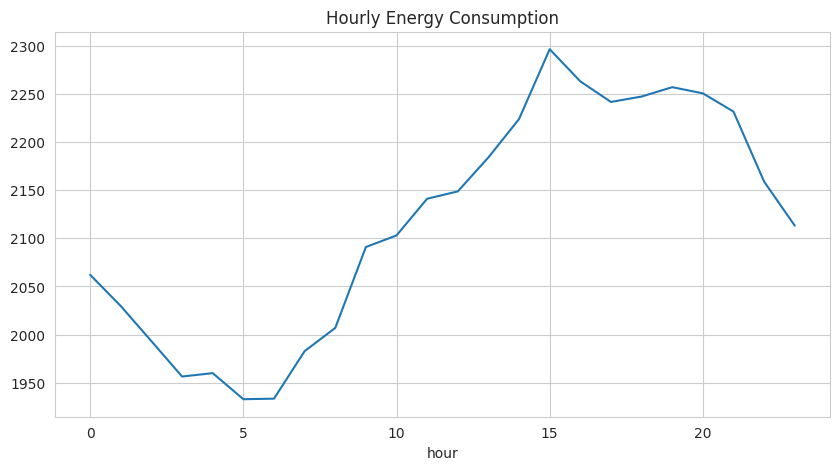

In [32]:
# 시간대별 소비 패턴
# 1. 낮 vs 밤
hourly = df.groupby('hour')['meter_reading'].mean()

plt.figure(figsize=(10,5))
hourly.plot()
plt.title('Hourly Energy Consumption')
plt.show()

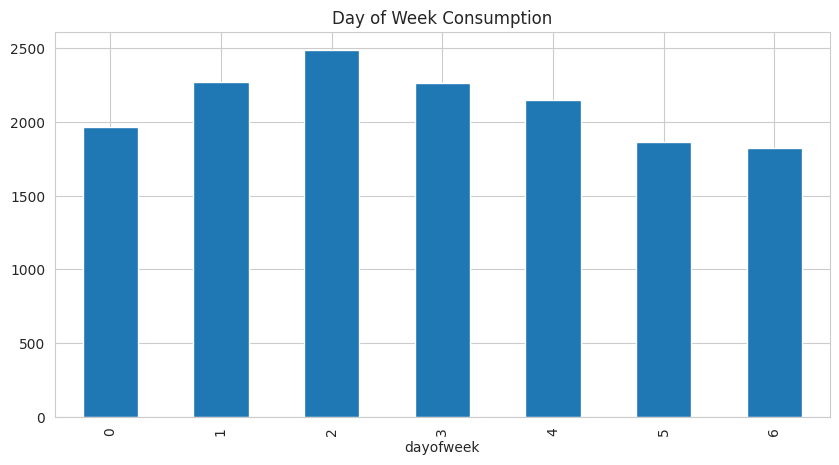

In [33]:
# 2. 요일별 패턴
dow = df.groupby('dayofweek')['meter_reading'].mean()

plt.figure(figsize=(10,5))
dow.plot(kind='bar')
plt.title('Day of Week Consumption')
plt.show()

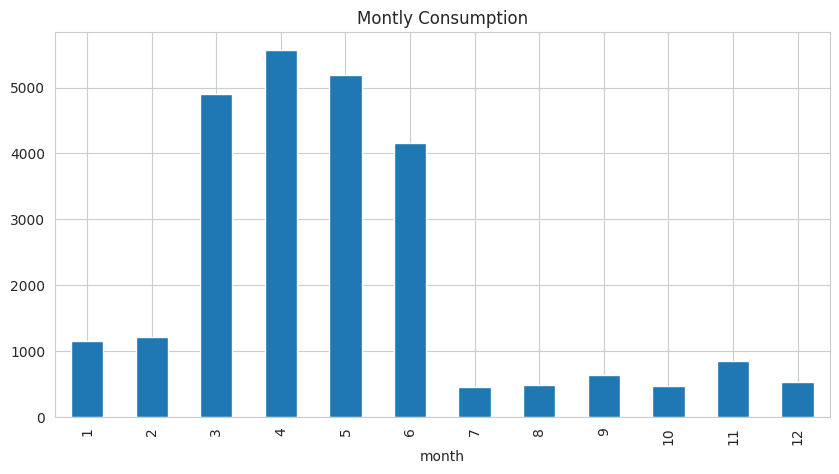

In [34]:
# 3. 월별 패턴
monthly = df.groupby('month')['meter_reading'].mean()

plt.figure(figsize=(10,5))
monthly.plot(kind='bar')
plt.title('Montly Consumption')
plt.show()

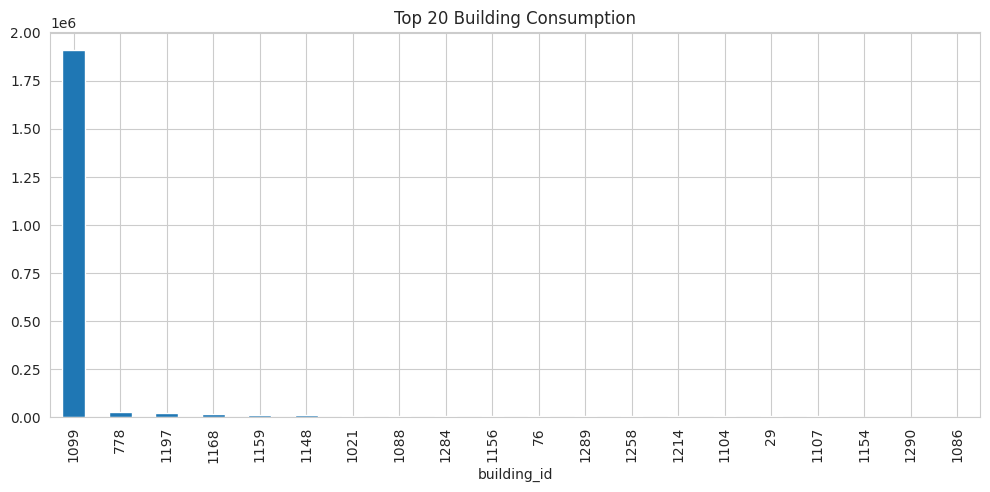

In [35]:
# 건물별 소비 분석
# 1. 건물별 평균 소비
building_usage = df.groupby('building_id')['meter_reading'].mean().sort_values(ascending=False)

building_usage.head(20).plot(kind='bar', figsize=(12,5))
plt.title('Top 20 Building Consumption')
plt.show()

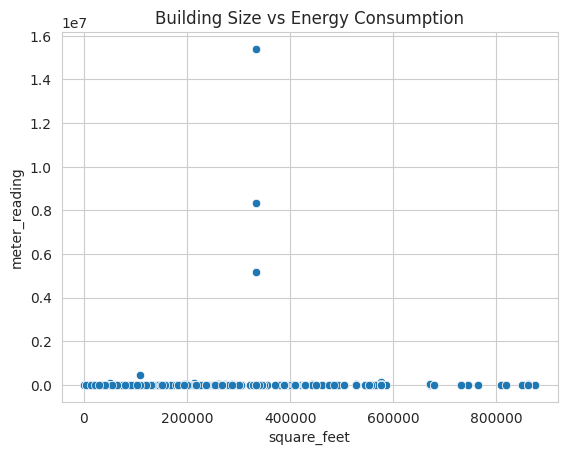

In [36]:
# 2.building size 영향
df['usage_per_sqft'] = df['meter_reading'] / df['square_feet']

sns.scatterplot(
    data=df.sample(10000),
    x='square_feet',
    y='meter_reading'
)
plt.title('Building Size vs Energy Consumption')
plt.show()

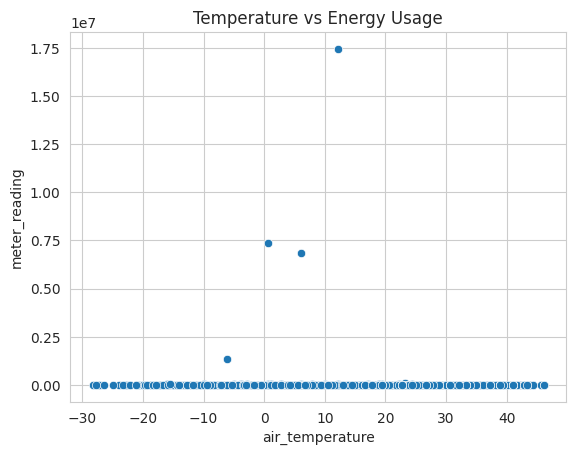

In [37]:
# 계절성 분석
# 1. 온도 영향
sns.scatterplot(
    data = df.sample(10000),
    x = 'air_temperature',
    y = 'meter_reading'
)
plt.title('Temperature vs Energy Usage')
plt.show()

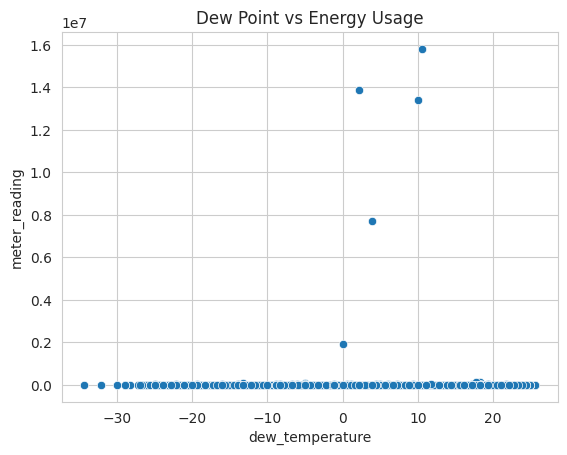

In [38]:
# 2.습도 영향
sns.scatterplot(
    data = df.sample(10000),
    x='dew_temperature',
    y='meter_reading'
)
plt.title('Dew Point vs Energy Usage')
plt.show()

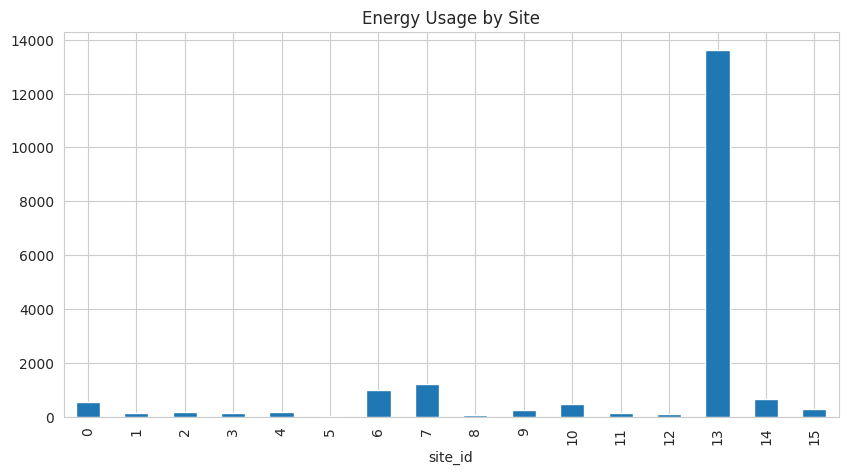

In [39]:
# 3.site별 차이
site_usage = df.groupby('site_id')['meter_reading'].mean()

site_usage.plot(kind='bar', figsize=(10,5))
plt.title('Energy Usage by Site')
plt.show()

In [40]:
df['meter'].value_counts()

,count
meter,
0,12060910
1,4182440
2,2708713
3,1264037


In [41]:
df_elec = df[df['meter'] == 0]  # 전기
df_chilled = df[df['meter'] == 1]  # 냉수
df_steam = df[df['meter'] == 2]  # 증기
df_hotwater = df[df['meter'] == 3]  # 온수

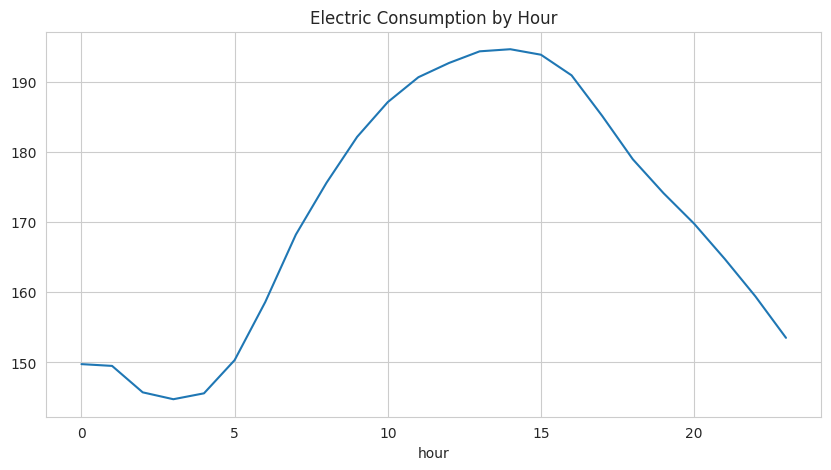

In [42]:
# meter별 EDA
# 1. 전기 소비 패턴
df_elec.groupby('hour')['meter_reading'].mean().plot(figsize=(10,5))
plt.title('Electric Consumption by Hour')
plt.show()

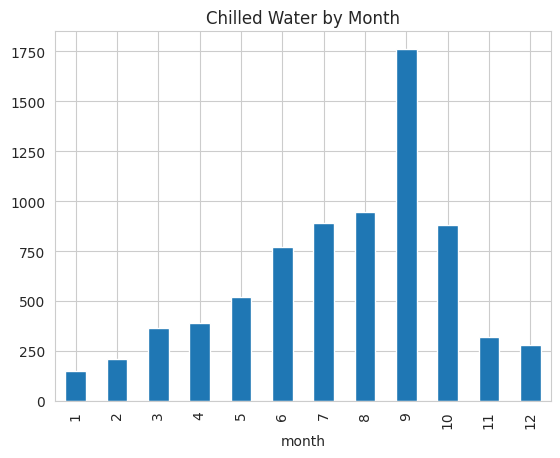

In [43]:
# 2. 냉방 에너지
df_chilled.groupby('month')['meter_reading'].mean().plot(kind='bar')
plt.title('Chilled Water by Month')
plt.show()

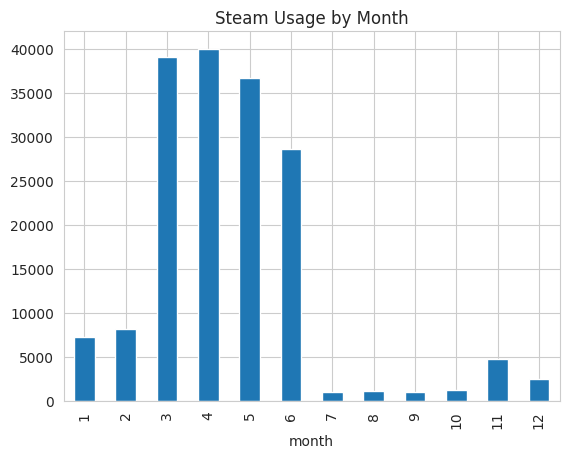

In [44]:
# 3. 증기 (난방)
df_steam.groupby('month')['meter_reading'].mean().plot(kind='bar')
plt.title('Steam Usage by Month')
plt.show()

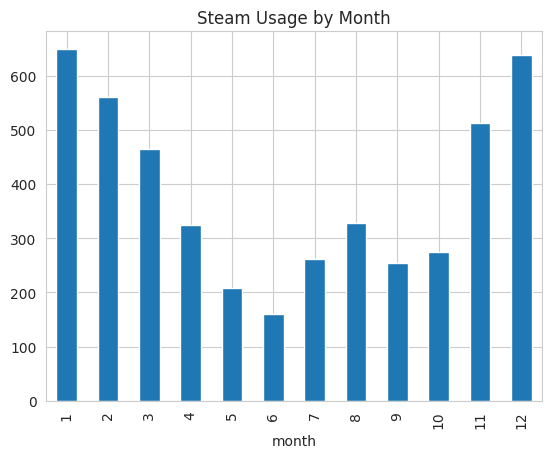

In [45]:
# 4. 온수 (난방)
df_hotwater.groupby('month')['meter_reading'].mean().plot(kind='bar')
plt.title('Steam Usage by Month')
plt.show()

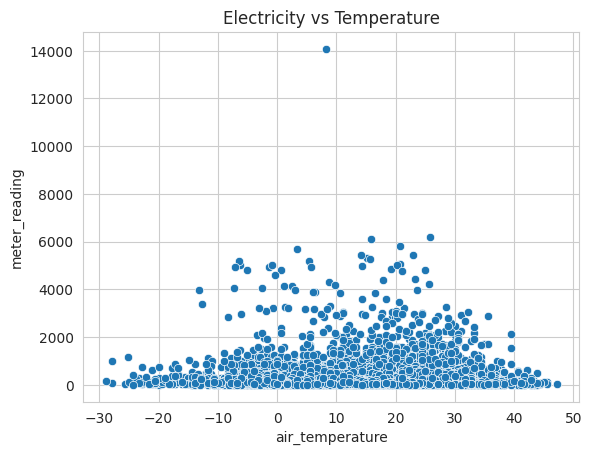

In [46]:
# meter + temperature
sns.scatterplot(
    data = df_elec.sample(20000),
    x = 'air_temperature',
    y = 'meter_reading'
)
plt.title('Electricity vs Temperature')
plt.show()

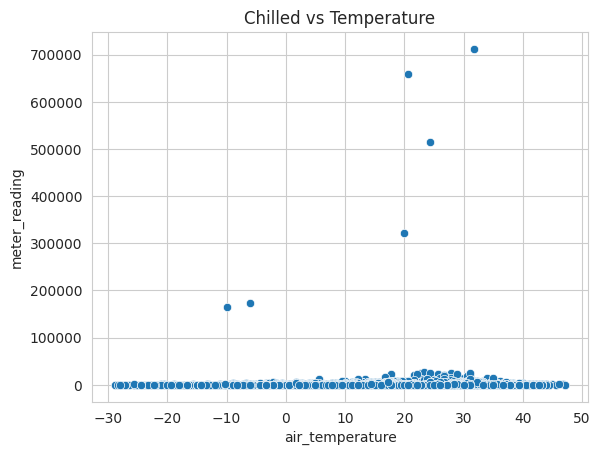

In [47]:
# meter + temperature
sns.scatterplot(
    data = df_chilled.sample(20000),
    x = 'air_temperature',
    y = 'meter_reading'
)
plt.title('Chilled vs Temperature')
plt.show()

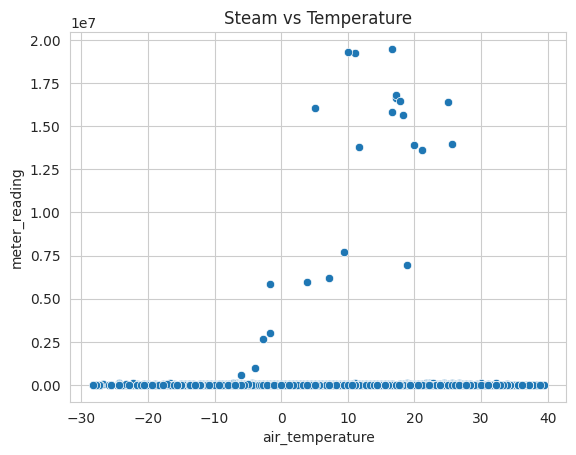

In [48]:
# meter + temperature
sns.scatterplot(
    data = df_steam.sample(20000),
    x = 'air_temperature',
    y = 'meter_reading'
)
plt.title('Steam vs Temperature')
plt.show()

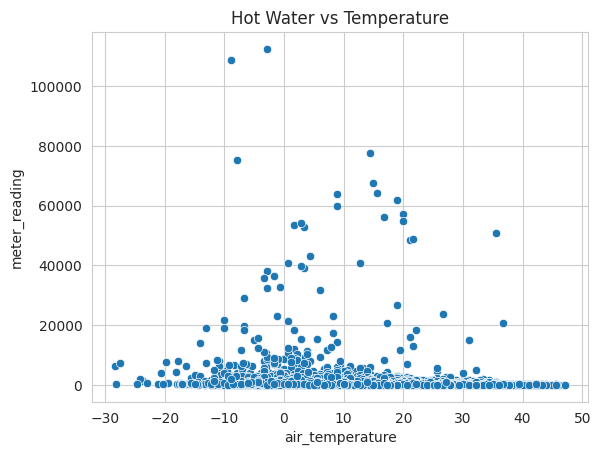

In [49]:
# meter + temperature
sns.scatterplot(
    data = df_hotwater.sample(20000),
    x = 'air_temperature',
    y = 'meter_reading'
)
plt.title('Hot Water vs Temperature')
plt.show()

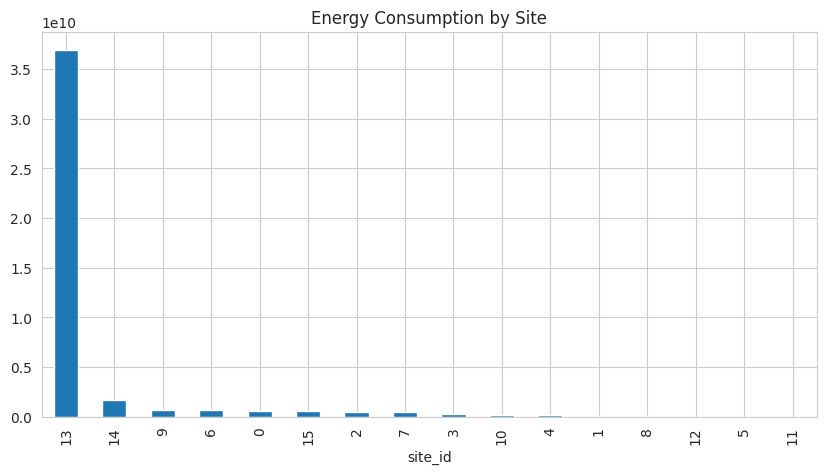

In [50]:
# site별 분석
site_energy = df.groupby('site_id')['meter_reading'].sum().sort_values(ascending=False)
site_energy.plot(kind='bar', figsize=(10,5))
plt.title('Energy Consumption by Site')
plt.show()

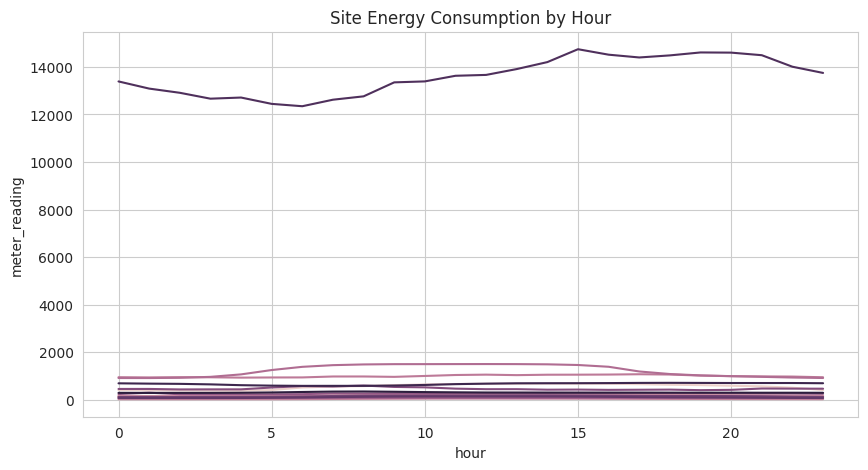

In [51]:
# site별 시간대 패턴
site_hour = df.groupby(['site_id', 'hour'])['meter_reading'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=site_hour, x='hour', y='meter_reading', hue='site_id', legend=False)
plt.title('Site Energy Consumption by Hour')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

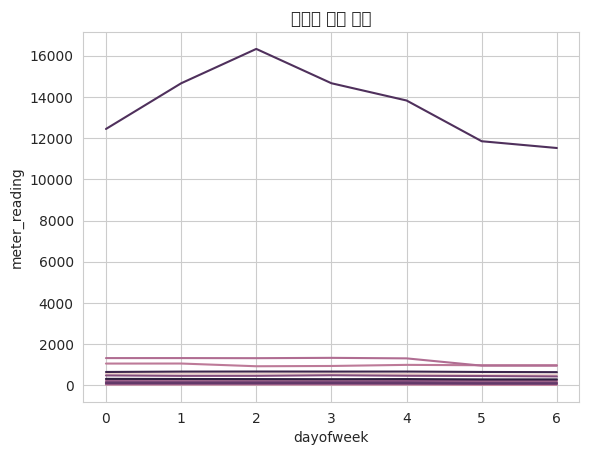

In [52]:
# site별 요일 패턴
# 업무용 vs 주거용 구분
site_week = df.groupby(['site_id','dayofweek'])['meter_reading'].mean().reset_index()

sns.lineplot(data=site_week, x='dayofweek', y='meter_reading', hue='site_id', legend=False)
plt.title('요일별 소비 패턴')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

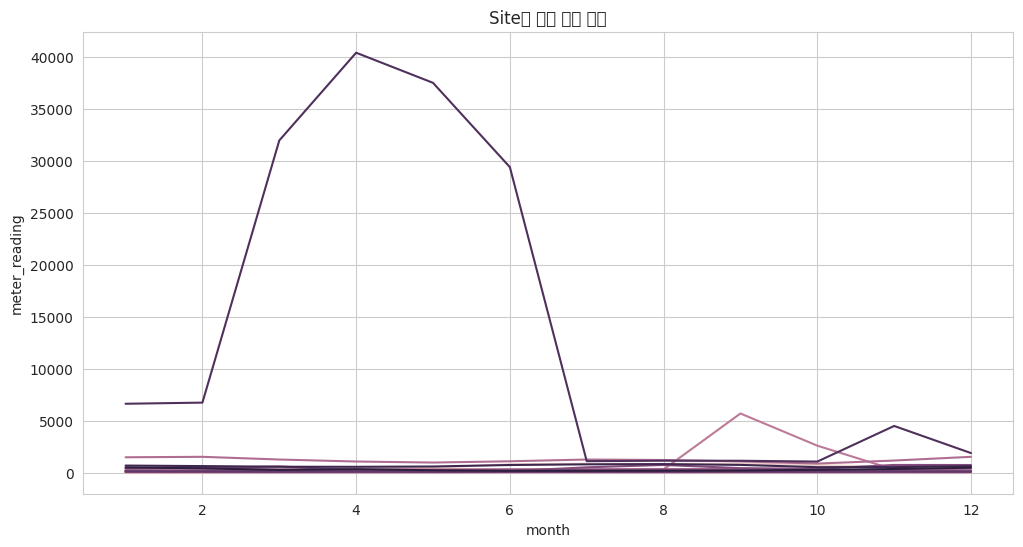

In [53]:
# site별 월별 분석 (계절성 분석)

site_month = df.groupby(['site_id','month'])['meter_reading'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=site_month, x='month', y='meter_reading', hue='site_id', legend=False)
plt.title('Site별 월별 소비 패턴')
plt.show()

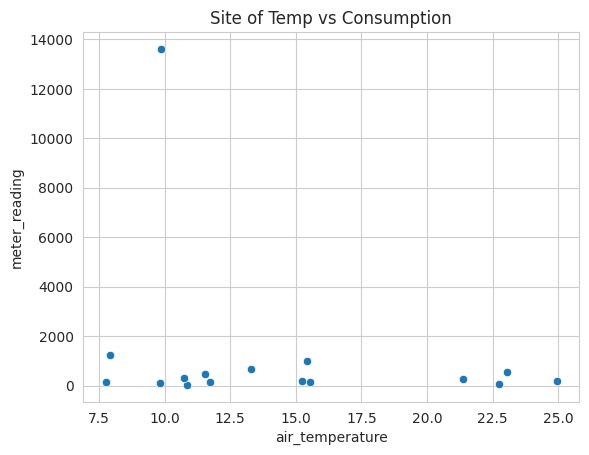

In [54]:
# site별 기온 vs 소비량

site_temp = df.groupby('site_id')[['air_temperature','meter_reading']].mean()

sns.scatterplot(data=site_temp, x='air_temperature', y='meter_reading')
plt.title('Site of Temp vs Consumption')
plt.show()

In [55]:
# site별 meter 종류 분포
pd.crosstab(df['site_id'], df['meter'])

meter,0,1,2,3
site_id,,,,
0,908409,168253,0,0
1,447982,0,0,105375
2,1184512,863845,0,481955
3,2370097,0,0,0
4,746746,0,0,0
5,781776,0,0,0
6,315436,164107,188590,0
7,104784,130956,104597,26344
8,567915,0,0,0
